# Load libraries

In [350]:
# Limitations: 
# Datasets are of differing years. I assume the relative impact of year to be neglible, but this may not be true
# Used Toronto 140 neighbourhoods instead of 158 to include more data
# In cases where multiple neighbourhood 158 points to the same 140, I take a simple mean. 
# This is a simplification, a better approach would be to account for population size first
# Due to the manual process, there may be errors in preprocessing

In [415]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import textwrap
import plotly.graph_objects as go
import plotly.express as px
import re

from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import kruskal
from sklearn.decomposition import PCA

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
pd.set_option("display.max_columns", None)

# Correlation

In [352]:
# Load data
df_merge_all = pd.read_excel("final_table.xlsx")

X_master = df_merge_all.drop(
    columns=[
        "NEIGHBOURHOOD_ID",
        "PercentVoted_df_dv"
    ]
)

# Numeric predictors only
X_numeric = X_master.select_dtypes(include=np.number)

# Correlation matrix

corr = X_numeric.corr()
cols = corr.columns


# P-value matrix

pvals = pd.DataFrame(
    np.nan,
    index=cols,
    columns=cols
)

for col1 in cols:
    for col2 in cols:

        if col1 == col2:
            pvals.loc[col1, col2] = 0
            continue

        valid = X_numeric[
            [col1, col2]
        ].dropna()

        if len(valid) >= 3:
            r, p = pearsonr(
                valid[col1],
                valid[col2]
            )

            pvals.loc[col1, col2] = p
            
# Create hover text matrix with same dimensions as correlation matrix
hover_text = np.empty(
    corr.shape,
    dtype=object
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):

        p = pvals.iloc[i, j]

        # Cleaner p-value formatting
        if p < 0.001:
            p_text = "< 0.001"
        else:
            p_text = f"{p:.3f}"

        hover_text[i, j] = (
            f"<b>{corr.columns[i]}</b><br>"
            f"vs. {corr.columns[j]}<br><br>"
            f"Pearson r: <b>{corr.iloc[i, j]:.2f}</b><br>"
            f"p-value: <b>{p_text}</b>"
        )


# Interactive heatmap

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,

        x=corr.columns,
        y=corr.index,

        text=hover_text,

        colorscale="RdBu_r",
        zmid=0,
        zmin=-1,
        zmax=1,

        xgap=1,
        ygap=1,

        colorbar=dict(
            title=dict(
                text="Pearson r",
                side="right"
            ),
            thickness=15,
            len=0.65,
            tickvals=[-1, -0.5, 0, 0.5, 1]
        ),

        hovertemplate=(
            "%{text}"
            "<extra></extra>"
        )
    )
)


# Layout

fig.update_layout(

    title=dict(
        text="Correlation Structure of Neighbourhood Predictors",
        x=0.02,
        xanchor="left",
        font=dict(
            size=22
        )
    ),

    width=1500,
    height=1400,

    paper_bgcolor="white",
    plot_bgcolor="white",

    font=dict(
        family="Arial",
        size=11
    ),

    margin=dict(
        l=280,
        r=100,
        t=100,
        b=280
    )
)


# X axis
fig.update_xaxes(
    tickangle=-45,
    side="bottom",
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=10)
)


# Y axis
fig.update_yaxes(
    autorange="reversed",
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=10)
)


fig.show()

fig.write_json(
    "correlation_matrix.json"
)

In [353]:
# Function that calculates pairwise correlation, conduct FDR correction, then visualizes the data
def examine_correlations(y):

    results = []

    X = df_merge_all.drop(
        columns=[
            "NEIGHBOURHOOD_ID",
            "NEIGHBOURHOOD",
            y
        ]
    )

    for col in X.columns:

        valid = df_merge_all[[col, y]].dropna()

        r, p = pearsonr(
            valid[col],
            valid[y]
        )

        results.append({
            "Variable": col,
            "Correlation": r,
            "p_value": p,
            "n": len(valid)
        })

    corr_y = pd.DataFrame(results)

    # FDR correction
    reject, p_fdr, _, _ = multipletests(
        corr_y["p_value"],
        alpha=0.05,
        method="fdr_bh"
    )

    corr_y["p_FDR"] = p_fdr
    corr_y["FDR_significant"] = reject

    # Sort strongest correlations first
    corr_y = corr_y.sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )

    # Only correlations surviving FDR
    significant_corr = corr_y[
        corr_y["FDR_significant"]
    ].copy()


    # Plot

    plot_df = significant_corr.sort_values(
        "Correlation"
    ).copy()

    # Optional: clean variable names for display
    plot_df["Label"] = (
        plot_df["Variable"]
    )

    y_label = (
        y
    )

    # Dynamic height depending on number of significant predictors
    fig_height = max(6, len(plot_df) * 0.4)

    fig, ax = plt.subplots(
        figsize=(11, fig_height)
    )

    # Different colors for negative vs positive correlations
    colors = [
        "steelblue" if r < 0 else "indianred"
        for r in plot_df["Correlation"]
    ]

    bars = ax.barh(
        plot_df["Label"],
        plot_df["Correlation"],
        color=colors,
        alpha=0.85
    )

    # Zero reference line
    ax.axvline(
        x=0,
        color="black",
        linewidth=1,
        linestyle="--"
    )

    # Add correlation value beside each bar
    for bar, r in zip(
        bars,
        plot_df["Correlation"]
    ):

        offset = 0.015 if r >= 0 else -0.015

        ax.text(
            r + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{r:.2f}",
            va="center",
            ha="left" if r >= 0 else "right",
            fontsize=9
        )

    # Make x-axis symmetric around zero
    max_corr = plot_df["Correlation"].abs().max()

    ax.set_xlim(
        -max_corr - 0.10,
        max_corr + 0.10
    )

    # Labels
    ax.set_xlabel(
        f"Pearson correlation with {y_label}",
        fontsize=11
    )

    ax.set_ylabel("")

    ax.set_title(
        f"Significant Correlations with {y_label}\n"
        "FDR-adjusted p < .05",
        fontsize=17,
        fontweight="bold",
        loc="left",
        pad=18
    )

    # Light vertical grid
    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.4
    )

    ax.set_axisbelow(True)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Improve tick appearance
    ax.tick_params(
        axis="y",
        length=0,
        labelsize=9,
        pad=12
    )

    ax.tick_params(
        axis="x",
        labelsize=9
    )

    plt.tight_layout()
    plt.subplots_adjust(left=0.35)
    plt.show()

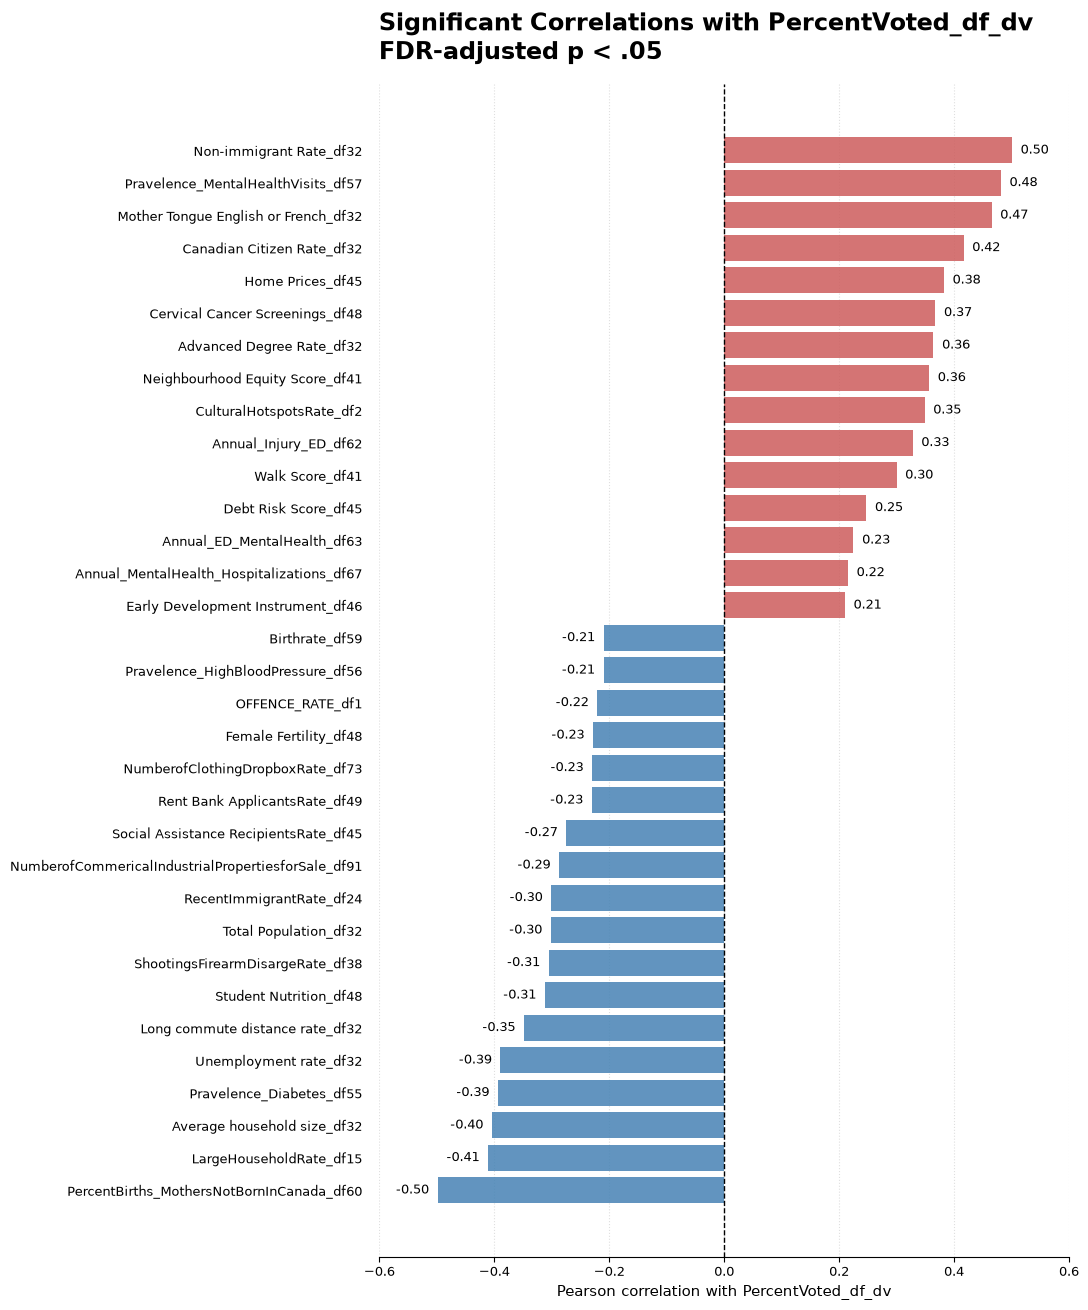

In [354]:
examine_correlations("PercentVoted_df_dv")

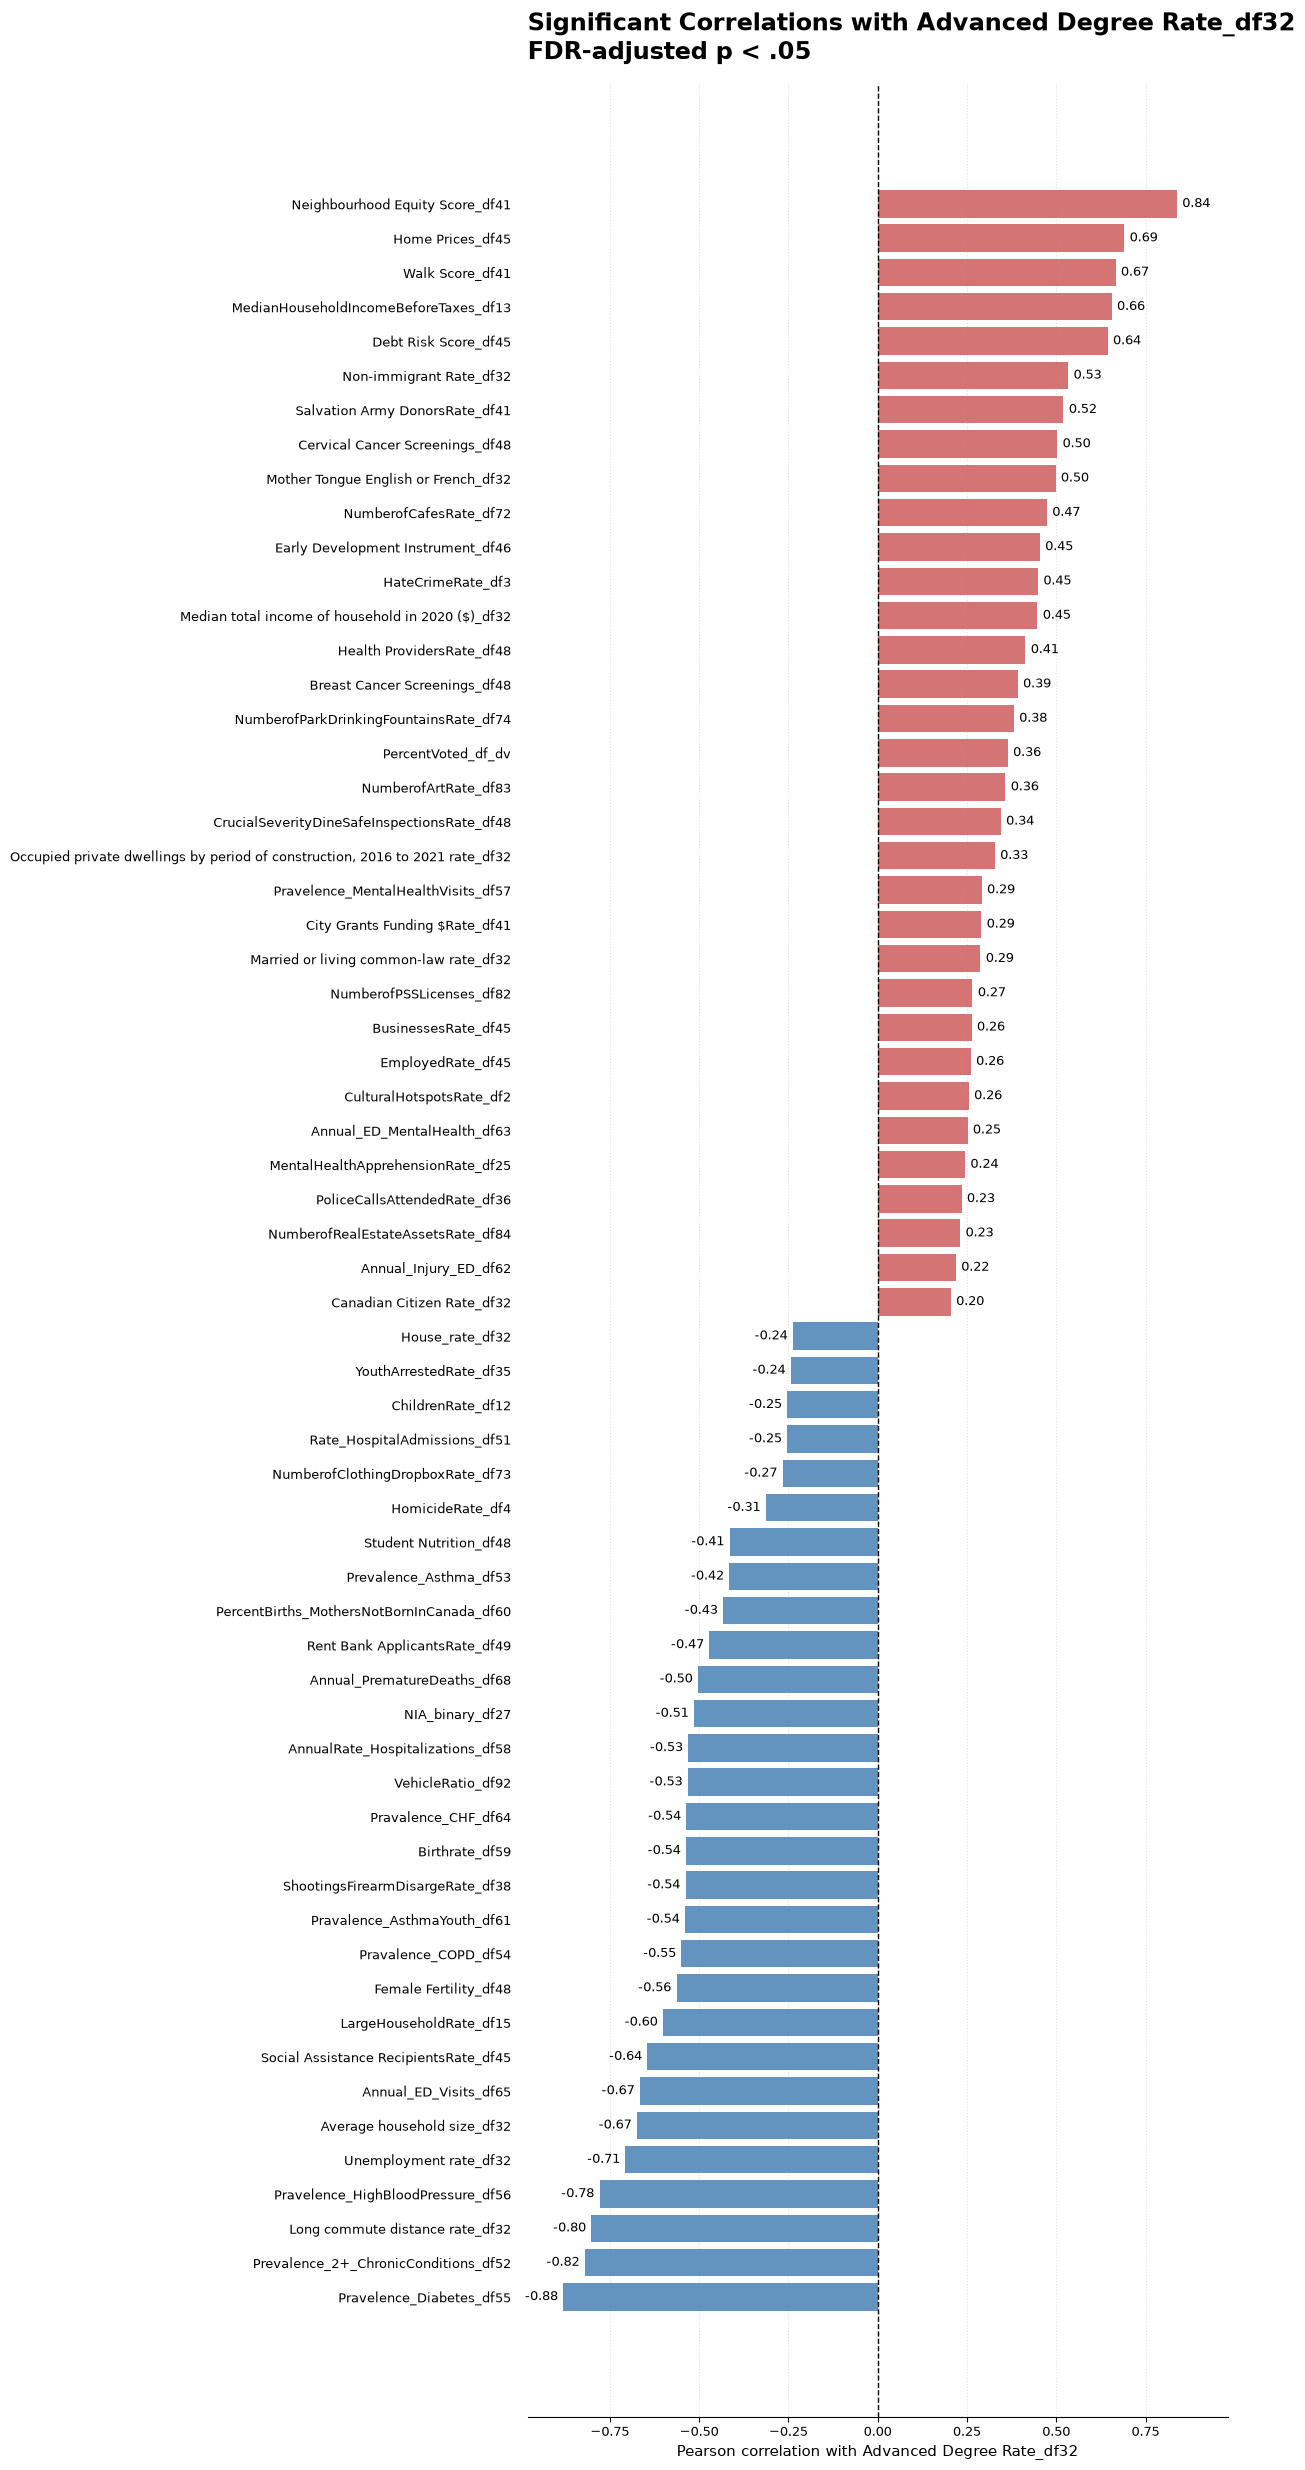

In [355]:
examine_correlations("Advanced Degree Rate_df32")

# Dendrogram

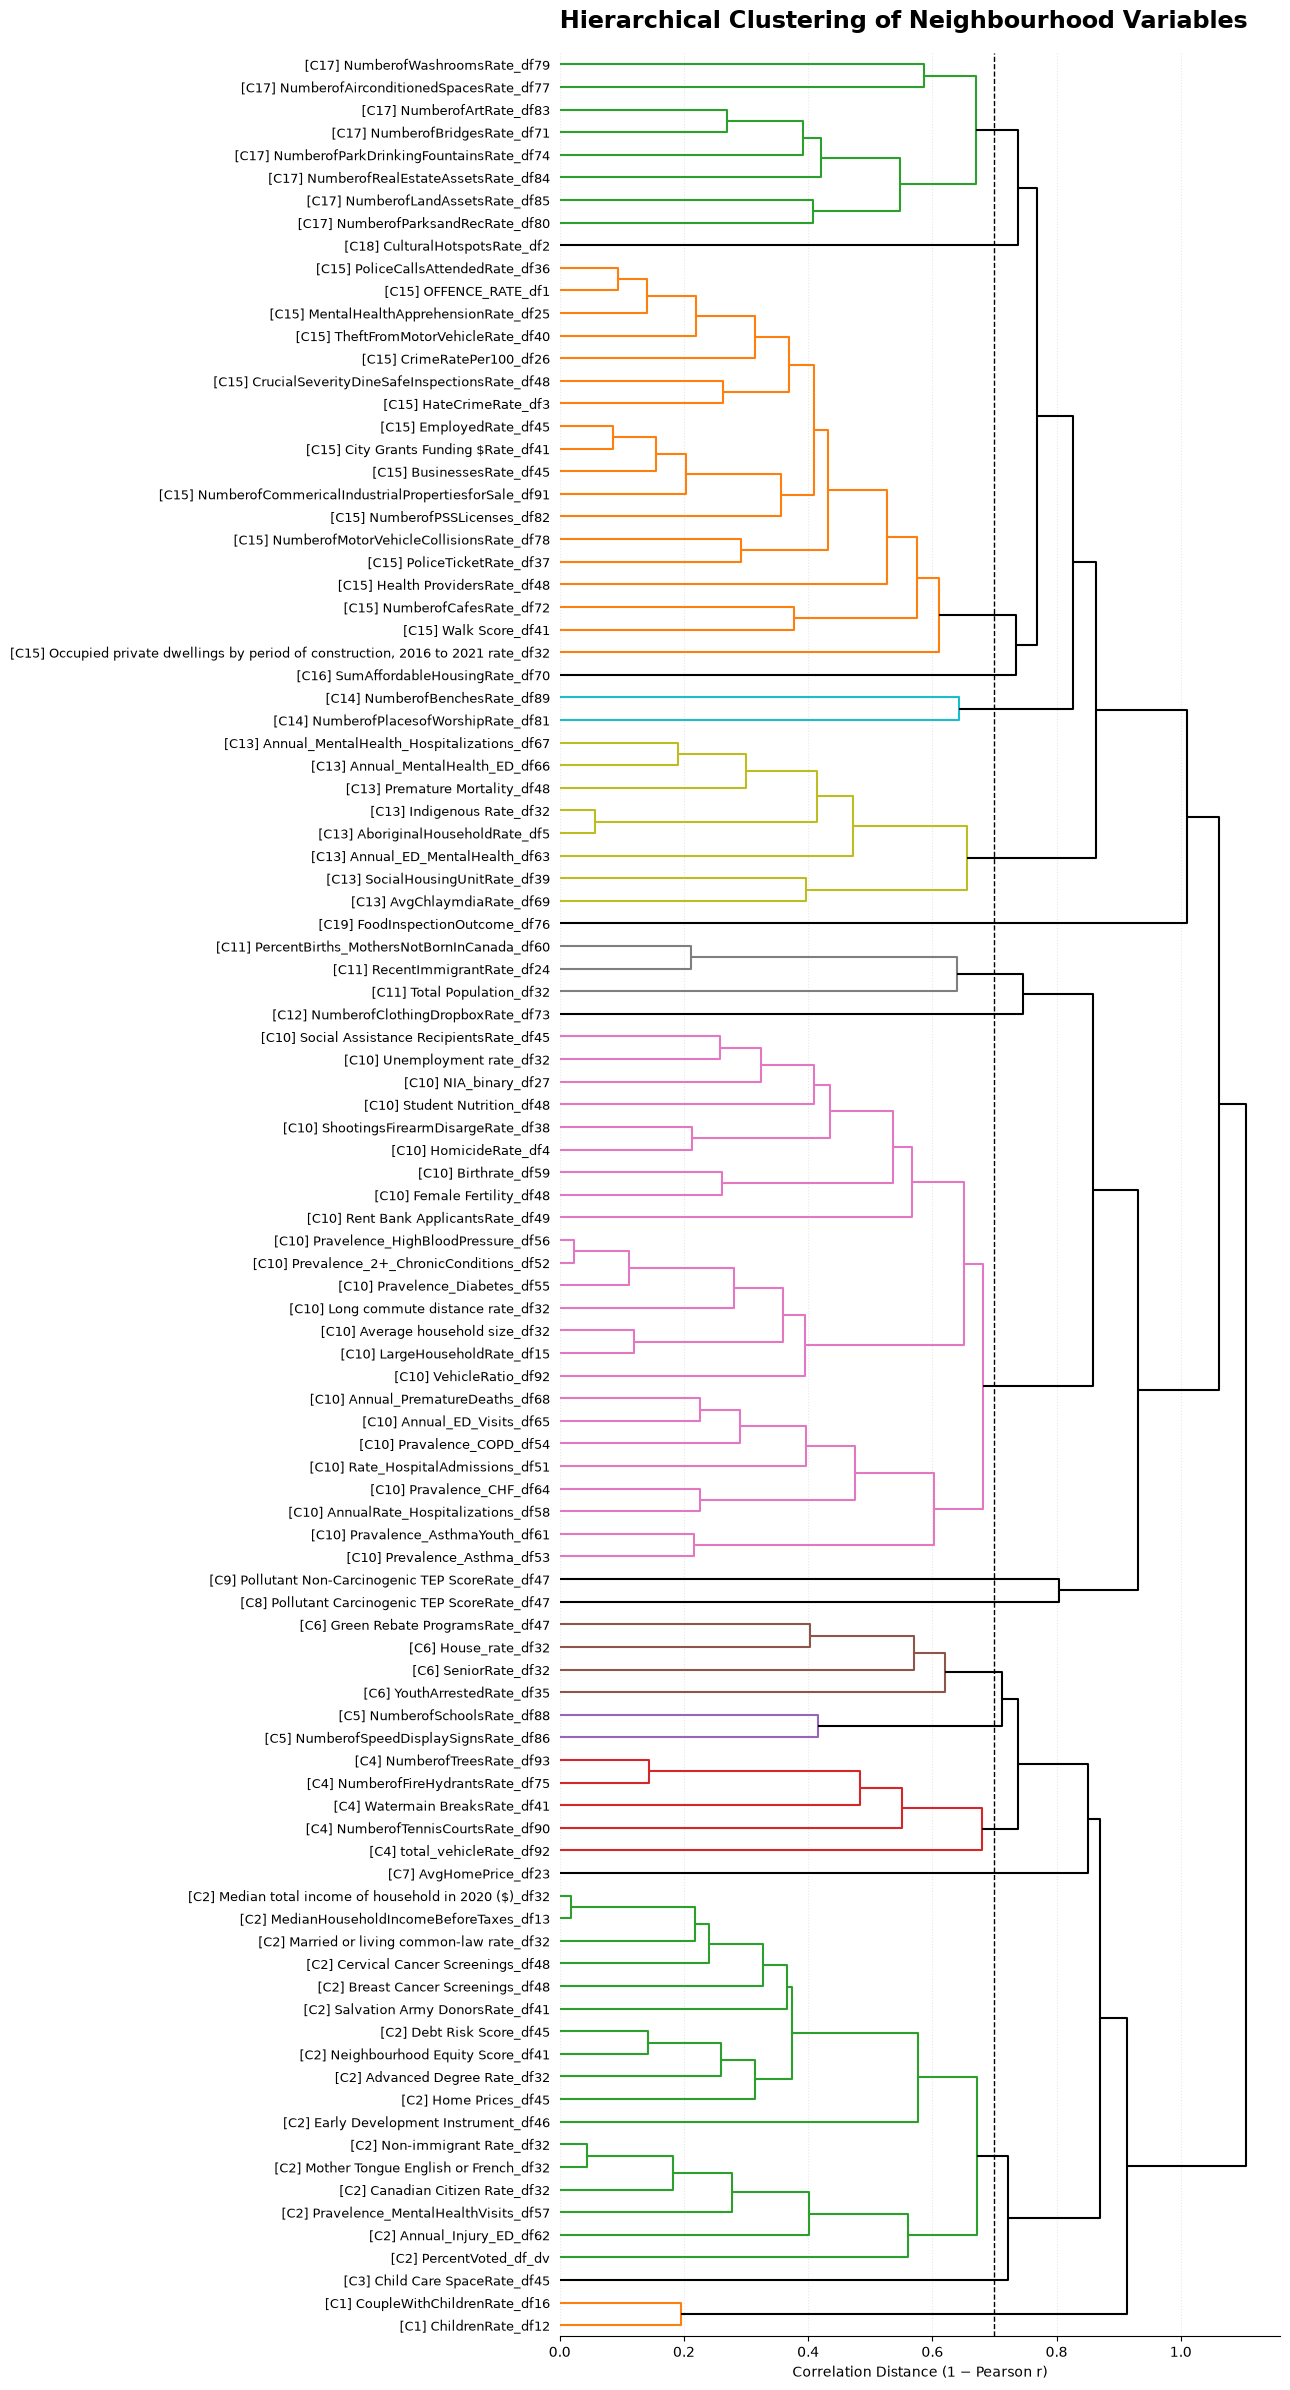

In [377]:
# All variables
X = df_merge_all.drop(
    columns=["NEIGHBOURHOOD_ID", "NEIGHBOURHOOD"]
)

# Numeric variables only
X = X.select_dtypes(include=np.number)

# Correlation matrix
corr = X.corr()

# Correlation distance
distance = 1 - corr

# Condensed matrix
distance_condensed = squareform(
    distance.values,
    checks=False
)

# Hierarchical clustering
Z = linkage(
    distance_condensed,
    method="average"
)

threshold = 0.7


# IMPORTANT:
# Generate VARIABLE cluster labels from this dendrogram
variable_cluster_labels = fcluster(
    Z,
    t=threshold,
    criterion="distance"
)

# Map variable name -> cluster
variable_cluster_map = dict(
    zip(
        X.columns,
        variable_cluster_labels
    )
)


# Cluster table
clusters = pd.DataFrame({
    "Variable": X.columns,
    "Cluster": variable_cluster_labels
})

clusters = clusters.sort_values(
    ["Cluster", "Variable"]
)


# Labels for plot
labels_with_cluster = [
    f"[C{variable_cluster_map[col]}] {col}"
    for col in X.columns
]


# Plot
fig, ax = plt.subplots(
    figsize=(13, 24)
)

dendrogram(
    Z,
    labels=labels_with_cluster,
    orientation="right",
    leaf_font_size=9,
    color_threshold=threshold,
    above_threshold_color="black",
    ax=ax
)

ax.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Hierarchical Clustering of Neighbourhood Variables",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.set_xlabel(
    "Correlation Distance (1 − Pearson r)"
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
for cluster, group in clusters.groupby("Cluster"):

    print(f"\nCluster {cluster}")

    for variable in group["Variable"]:
        print("  ", variable)


Cluster 1
   ChildrenRate_df12
   CoupleWithChildrenRate_df16

Cluster 2
   Annual_Injury_ED_df62
   Canadian Citizen Rate_df32
   Mother Tongue English or French_df32
   Non-immigrant Rate_df32
   Pravelence_MentalHealthVisits_df57

Cluster 3
   PercentVoted_df_dv

Cluster 4
   Advanced Degree Rate_df32
   Breast Cancer Screenings_df48
   Cervical Cancer Screenings_df48
   Debt Risk Score_df45
   Home Prices_df45
   Married or living common-law rate_df32
   Median total income of household in 2020 ($)_df32
   MedianHouseholdIncomeBeforeTaxes_df13
   Neighbourhood Equity Score_df41
   Salvation Army DonorsRate_df41

Cluster 5
   Early Development Instrument_df46

Cluster 6
   Child Care SpaceRate_df45

Cluster 7
   NumberofFireHydrantsRate_df75
   NumberofTreesRate_df93
   Watermain BreaksRate_df41

Cluster 8
   NumberofTennisCourtsRate_df90

Cluster 9
   total_vehicleRate_df92

Cluster 10
   NumberofSchoolsRate_df88
   NumberofSpeedDisplaySignsRate_df86

Cluster 11
   Green Rebate Pr

# Clustering Neighbourhoods

In [398]:
# Keep neighbourhood information separately
neighbourhood_info = df_merge_all[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
].copy()


# Use all numeric variables for clustering
# Only exclude neighbourhood identifiers/names
X_neighbourhoods = (
    df_merge_all
    .drop(
        columns=[
            "NEIGHBOURHOOD_ID",
            "NEIGHBOURHOOD"
        ]
    )
    .select_dtypes(include="number")
)

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_imputed
)

silhouette_results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(
        X_scaled
    )

    silhouette_results.append({
        "k": k,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        )
    })


silhouette_df = pd.DataFrame(
    silhouette_results
)

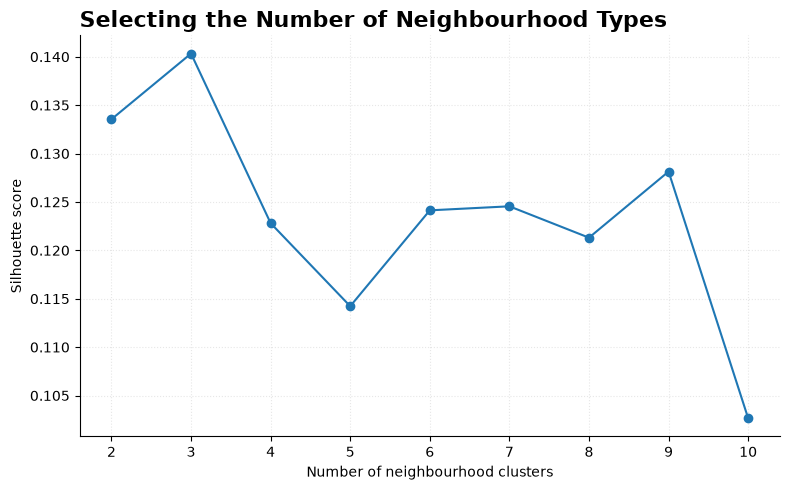

In [399]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    silhouette_df["k"],
    silhouette_df["Silhouette"],
    marker="o"
)

ax.set_xticks(
    silhouette_df["k"]
)

ax.set_xlabel(
    "Number of neighbourhood clusters"
)

ax.set_ylabel(
    "Silhouette score"
)

ax.set_title(
    "Selecting the Number of Neighbourhood Types",
    fontsize=16,
    fontweight="bold",
    loc="left"
)

ax.grid(
    linestyle=":",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [400]:
k = 9

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=50
)

# +1 so clusters are 1, 2, 3 instead of 0, 1, 2
neighbourhood_cluster_labels = (
    kmeans.fit_predict(X_scaled)
    + 1
)

cluster_lookup = df_merge_all[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
].copy()

cluster_lookup["Cluster"] = (
    neighbourhood_cluster_labels
)

neighbourhood_clusters

,NEIGHBOURHOOD_ID,NEIGHBOURHOOD,Cluster
0,1,West Humber-Clairville (1),2
1,2,Mount Olive-Silverstone-Jamestown (2),7
2,3,Thistletown-Beaumond Heights (3),7
3,4,Rexdale-Kipling (4),7
4,5,Elms-Old Rexdale (5),7
...,...,...,...
135,136,West Hill (136),7
136,137,Woburn (137),2
137,138,Eglinton East (138),7
138,139,Scarborough Village (139),7


In [401]:
X_standardized = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_standardized["Cluster"] = (
    neighbourhood_cluster_labels
)


cluster_profiles = (
    X_standardized
    .groupby("Cluster")
    .mean()
)

for cluster in cluster_profiles.index:

    z_profile = (
        cluster_profiles
        .loc[cluster]
        .sort_values(
            key=abs,
            ascending=False
        )
        .head(10)
    )

    print(
        f"\n========== CLUSTER {cluster} =========="
    )

    for variable, z in z_profile.items():

        original_mean = (
            cluster_original_means
            .loc[cluster, variable]
        )

        direction = (
            "above"
            if z > 0
            else "below"
        )

        print(
            f"{variable}: "
            f"{z:.2f} SD {direction} average "
            f"(cluster mean = {original_mean:.2f})"
        )


========== CLUSTER 1 ==========
Watermain BreaksRate_df41: 1.57 SD above average (cluster mean = 0.12)
YouthArrestedRate_df35: 1.49 SD above average (cluster mean = 0.14)
SeniorRate_df32: 1.27 SD above average (cluster mean = 0.48)
Pravalence_CHF_df64: 1.23 SD above average (cluster mean = 2.74)
Pravelence_HighBloodPressure_df56: 1.16 SD above average (cluster mean = 29.74)
Walk Score_df41: -1.13 SD below average (cluster mean = 57.89)
Salvation Army DonorsRate_df41: 1.09 SD above average (cluster mean = 6.43)
House_rate_df32: 1.09 SD above average (cluster mean = 0.63)
Canadian Citizen Rate_df32: 1.08 SD above average (cluster mean = 0.92)
RecentImmigrantRate_df24: -0.97 SD below average (cluster mean = 0.02)

========== CLUSTER 2 ==========
NumberofFireHydrantsRate_df75: 1.70 SD above average (cluster mean = 3.09)
NumberofClothingDropboxRate_df73: 1.30 SD above average (cluster mean = 0.06)
ShootingsFirearmDisargeRate_df38: 1.22 SD above average (cluster mean = 0.58)
NumberofSchools

In [402]:
# Create neighbourhood → cluster lookup

cluster_lookup = df_merge_all[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
].copy()

cluster_lookup["Cluster"] = (
    neighbourhood_cluster_labels
)


# Load Toronto neighbourhood polygons

neighbourhoods_map = gpd.read_file(
    "ZZ_voting/neighbourhoods140.geojson"
)

# Make map neighbourhood ID match df_merge_all
neighbourhoods_map["NEIGHBOURHOOD_ID"] = (
    neighbourhoods_map["AREA_SHORT_CODE"]
    .astype(int)
)


# Join clusters onto neighbourhood polygons

map_df = neighbourhoods_map.merge(
    cluster_lookup,
    on="NEIGHBOURHOOD_ID",
    how="left"
)


map_df[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD",
        "Cluster"
    ]
]

,NEIGHBOURHOOD_ID,NEIGHBOURHOOD,Cluster
0,79,University (79),9
1,111,Rockcliffe-Smythe (111),7
2,19,Long Branch (19),8
3,132,Malvern (132),2
4,12,Markland Wood (12),1
...,...,...,...
135,117,L'Amoreaux (117),2
136,110,Keelesdale-Eglinton West (110),7
137,78,Kensington-Chinatown (78),9
138,72,Regent Park (72),4


In [ ]:
X_standardized = pd.DataFrame(
    X_scaled,
    columns=X_neighbourhoods.columns
)

X_standardized["Cluster"] = (
    neighbourhood_cluster_labels
)

cluster_profiles = (
    X_standardized
    .groupby("Cluster")
    .mean()
)

cluster_profiles

,PercentVoted_df_dv,AboriginalHouseholdRate_df5,ChildrenRate_df12,MedianHouseholdIncomeBeforeTaxes_df13,LargeHouseholdRate_df15,CoupleWithChildrenRate_df16,AvgHomePrice_df23,RecentImmigrantRate_df24,CrimeRatePer100_df26,NIA_binary_df27,Total Population_df32,SeniorRate_df32,Married or living common-law rate_df32,House_rate_df32,Average household size_df32,Median total income of household in 2020 ($)_df32,"Occupied private dwellings by period of construction, 2016 to 2021 rate_df32",Mother Tongue English or French_df32,Indigenous Rate_df32,Canadian Citizen Rate_df32,Non-immigrant Rate_df32,Unemployment rate_df32,Advanced Degree Rate_df32,Long commute distance rate_df32,YouthArrestedRate_df35,Neighbourhood Equity Score_df41,Walk Score_df41,Debt Risk Score_df45,Home Prices_df45,Early Development Instrument_df46,Breast Cancer Screenings_df48,Cervical Cancer Screenings_df48,Female Fertility_df48,Premature Mortality_df48,Student Nutrition_df48,Rate_HospitalAdmissions_df51,Prevalence_2+_ChronicConditions_df52,Prevalence_Asthma_df53,Pravalence_COPD_df54,Pravelence_Diabetes_df55,Pravelence_HighBloodPressure_df56,Pravelence_MentalHealthVisits_df57,AnnualRate_Hospitalizations_df58,Birthrate_df59,PercentBirths_MothersNotBornInCanada_df60,Pravalence_AsthmaYouth_df61,Annual_Injury_ED_df62,Annual_ED_MentalHealth_df63,Pravalence_CHF_df64,Annual_ED_Visits_df65,Annual_MentalHealth_ED_df66,Annual_MentalHealth_Hospitalizations_df67,Annual_PrematureDeaths_df68,AvgChlaymdiaRate_df69,FoodInspectionOutcome_df76,NumberofPSSLicenses_df82,NumberofCommericalIndustrialPropertiesforSale_df91,VehicleRatio_df92,OFFENCE_RATE_df1,CulturalHotspotsRate_df2,HateCrimeRate_df3,HomicideRate_df4,MentalHealthApprehensionRate_df25,PoliceCallsAttendedRate_df36,PoliceTicketRate_df37,ShootingsFirearmDisargeRate_df38,SocialHousingUnitRate_df39,TheftFromMotorVehicleRate_df40,City Grants Funding $Rate_df41,Salvation Army DonorsRate_df41,Watermain BreaksRate_df41,BusinessesRate_df45,Child Care SpaceRate_df45,EmployedRate_df45,Social Assistance RecipientsRate_df45,Green Rebate ProgramsRate_df47,Pollutant Carcinogenic TEP ScoreRate_df47,Pollutant Non-Carcinogenic TEP ScoreRate_df47,CrucialSeverityDineSafeInspectionsRate_df48,Health ProvidersRate_df48,Rent Bank ApplicantsRate_df49,SumAffordableHousingRate_df70,NumberofBridgesRate_df71,NumberofCafesRate_df72,NumberofClothingDropboxRate_df73,NumberofParkDrinkingFountainsRate_df74,NumberofFireHydrantsRate_df75,NumberofAirconditionedSpacesRate_df77,NumberofMotorVehicleCollisionsRate_df78,NumberofWashroomsRate_df79,NumberofParksandRecRate_df80,NumberofPlacesofWorshipRate_df81,NumberofArtRate_df83,NumberofRealEstateAssetsRate_df84,NumberofLandAssetsRate_df85,NumberofSpeedDisplaySignsRate_df86,NumberofSchoolsRate_df88,NumberofBenchesRate_df89,NumberofTennisCourtsRate_df90,total_vehicleRate_df92,NumberofTreesRate_df93
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.350131,0.172147,-0.281763,0.353333,-0.024460,0.434236,0.469074,-0.965402,-0.662580,-0.533295,-0.481040,1.266690,0.755680,1.086926,0.322261,0.540224,-0.454703,0.329259,0.086899,1.083016,0.532191,-0.356701,-0.408474,0.016273,1.490464,0.317352,-1.128515,0.894326,-0.061353,0.471262,0.423880,0.672712,-0.688634,-0.224317,-0.587242,0.144576,0.965272,0.835273,0.809463,0.314338,1.157977,0.159474,0.882922,-0.478363,-0.563593,0.924127,0.957635,-0.064580,1.233158,0.205593,-0.579131,-0.472703,0.407439,-0.679636,-0.945987,-0.666222,-0.324694,0.735937,-0.664897,-0.106257,-0.397290,-0.267599,-0.691827,-0.658889,-0.522231,-0.432061,-0.374082,-0.313747,-0.250763,1.090615,1.566200,-0.562206,0.252734,-0.327217,-0.761354,0.472408,0.717194,0.280406,-0.538643,-0.656814,-0.423020,-0.452728,0.188741,-0.481750,0.172110,-0.301711,0.659347,-0.086725,-0.432540,0.835121,0.634271,-0.478745,-0.306184,-0.147082,0.277136,0.652248,-0.108294,-0.028919,0.688034,0.501999,0.777622
2,-0.962818,-0.389462,0.030335,-0.198201,0.329477,-0.075708,-0.166390,0

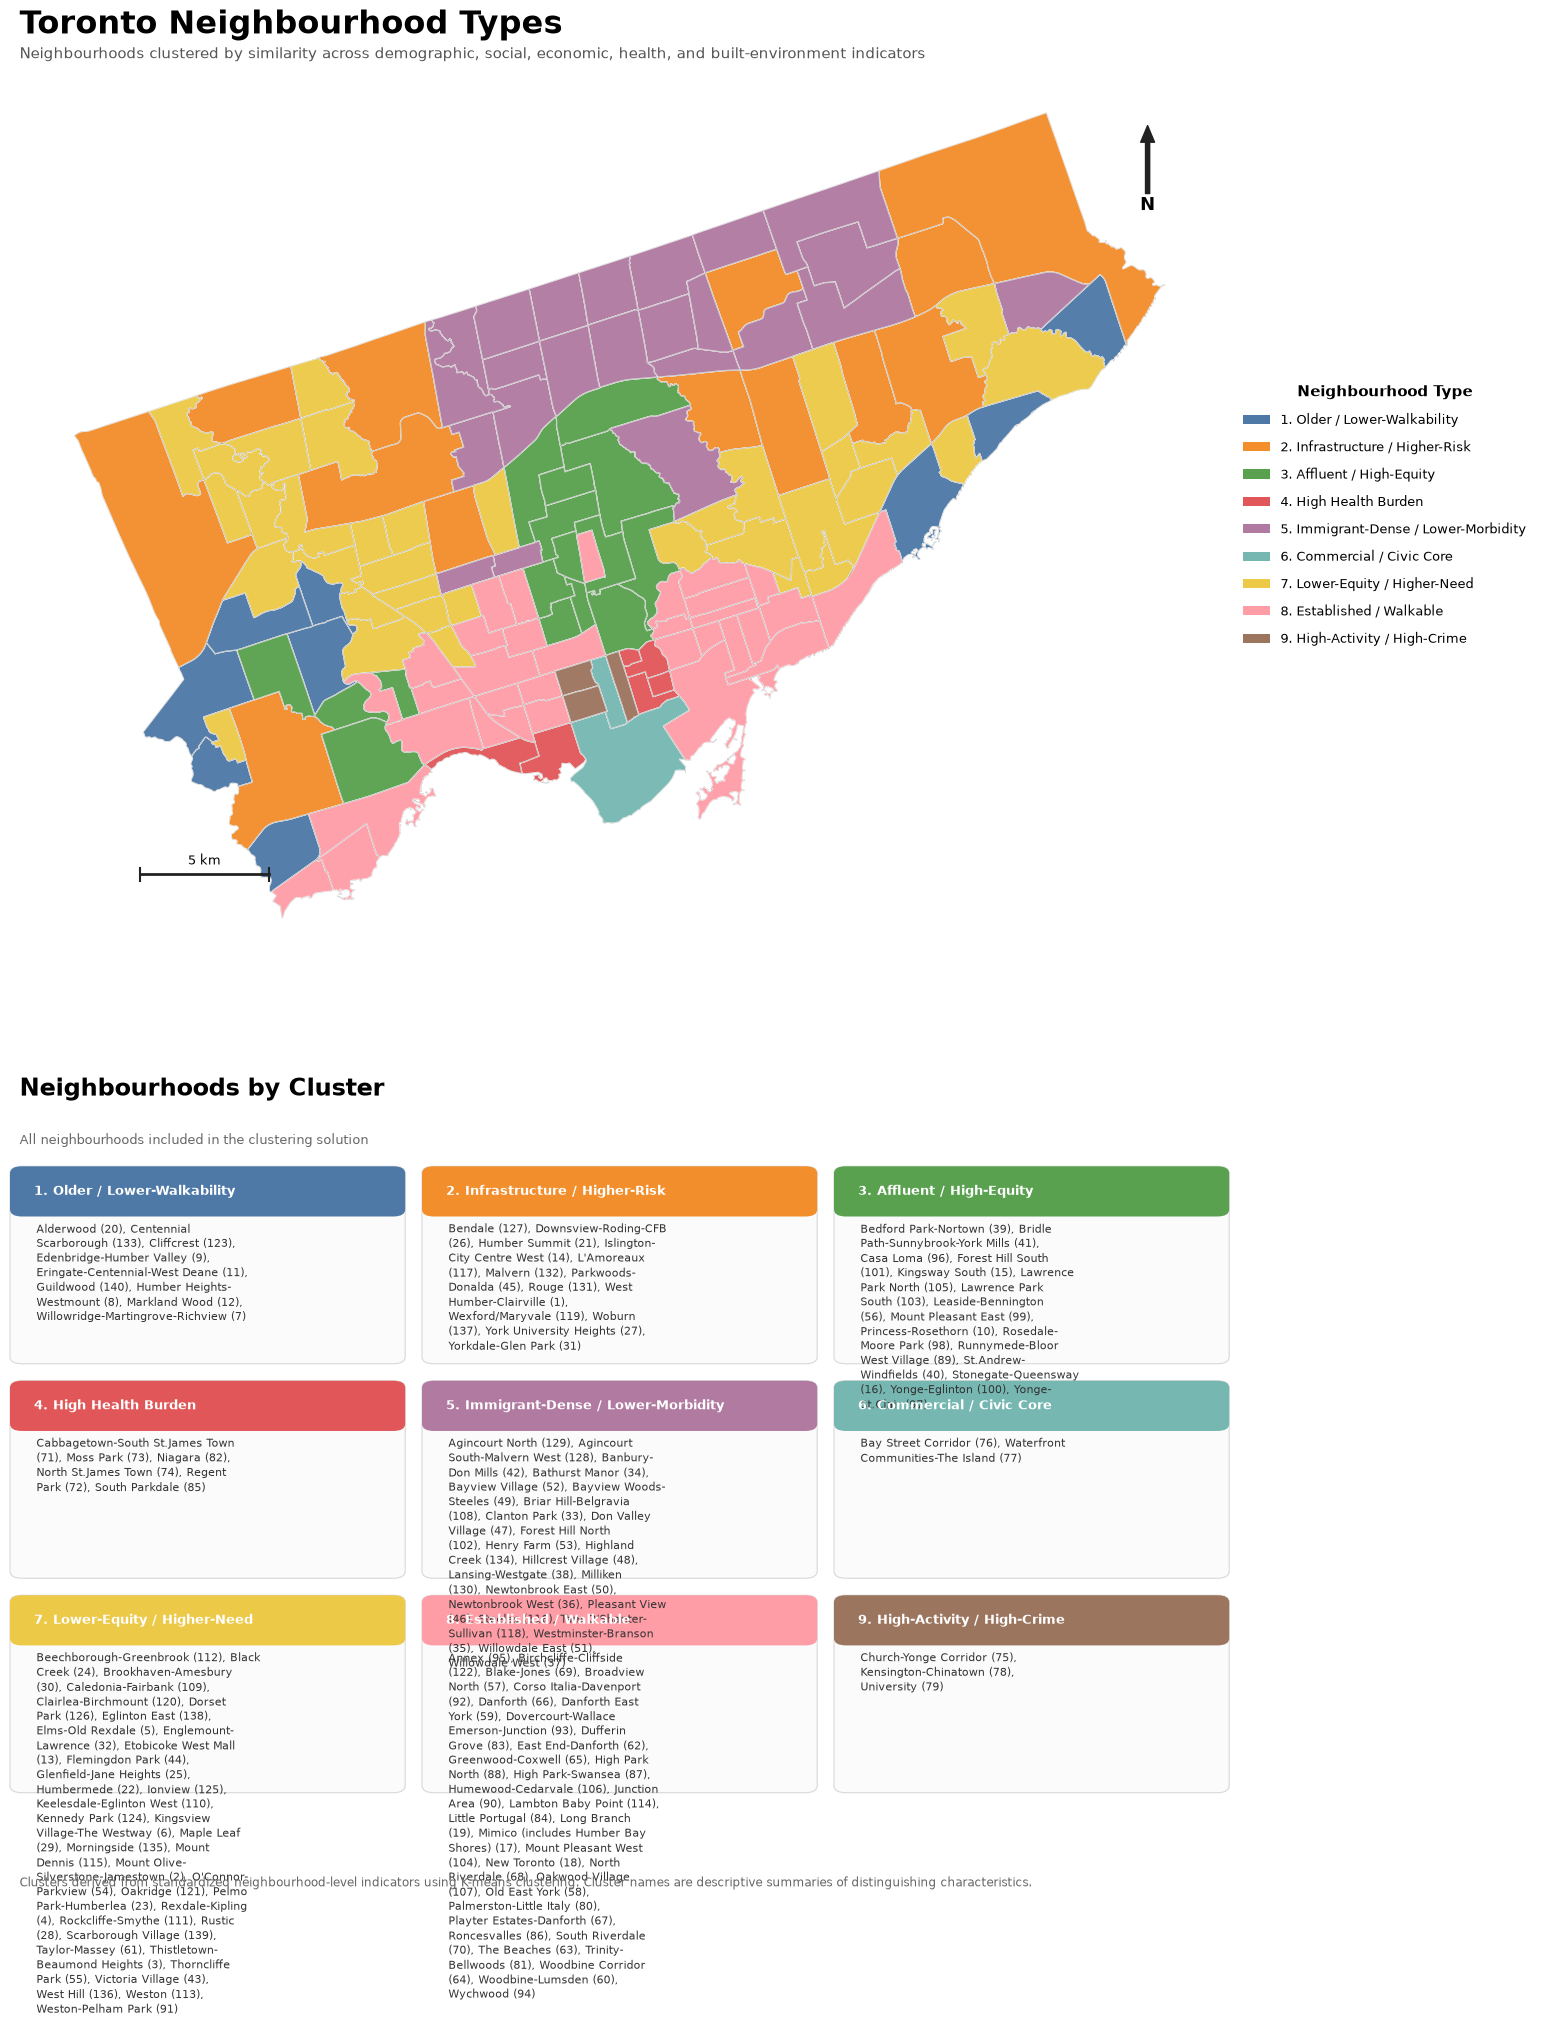

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.gridspec import GridSpec
import textwrap


# Cluster names

cluster_names = {
    1: "Older / Lower-Walkability",
    2: "Infrastructure / Higher-Risk",
    3: "Affluent / High-Equity",
    4: "High Health Burden",
    5: "Immigrant-Dense / Lower-Morbidity",
    6: "Commercial / Civic Core",
    7: "Lower-Equity / Higher-Need",
    8: "Established / Walkable",
    9: "High-Activity / High-Crime"
}

cluster_colors = {
    1: "#4E79A7",
    2: "#F28E2B",
    3: "#59A14F",
    4: "#E15759",
    5: "#B07AA1",
    6: "#76B7B2",
    7: "#EDC948",
    8: "#FF9DA7",
    9: "#9C755F"
}


# Project map into metres

map_plot = map_df.to_crs("EPSG:26917").copy()

clusters = sorted(
    map_plot["Cluster"]
    .dropna()
    .astype(int)
    .unique()
)


# Figure layout

fig = plt.figure(
    figsize=(16, 20),
    facecolor="white"
)

gs = GridSpec(
    2,
    1,
    height_ratios=[2.25, 1.55],
    hspace=0.10
)

ax = fig.add_subplot(gs[0])


# Draw map

for cluster in clusters:

    subset = map_plot[
        map_plot["Cluster"] == cluster
    ]

    subset.plot(
        ax=ax,
        color=cluster_colors[cluster],
        edgecolor="white",
        linewidth=0.85,
        alpha=0.96
    )

missing = map_plot[
    map_plot["Cluster"].isna()
]

if len(missing) > 0:
    missing.plot(
        ax=ax,
        color="#D9D9D9",
        edgecolor="white",
        linewidth=0.8
    )

map_plot.boundary.plot(
    ax=ax,
    color="#444444",
    linewidth=0.25,
    alpha=0.35
)


# Title and subtitle

ax.set_title(
    "Toronto Neighbourhood Types",
    fontsize=23,
    fontweight="bold",
    loc="left",
    pad=28
)

ax.text(
    0,
    1.012,
    "Neighbourhoods clustered by similarity across demographic, social, economic, health, and built-environment indicators",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#555555",
    va="bottom"
)


# Legend

legend_handles = [
    Patch(
        facecolor=cluster_colors[c],
        edgecolor="none",
        label=f"{c}. {cluster_names[c]}"
    )
    for c in clusters
]

legend = ax.legend(
    handles=legend_handles,
    title="Neighbourhood Type",
    loc="center left",
    bbox_to_anchor=(1.01, 0.50),
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5,
    labelspacing=1.0
)

legend.get_title().set_fontweight("bold")


# North arrow

ax.annotate(
    "N",
    xy=(0.94, 0.94),
    xytext=(0.94, 0.85),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    arrowprops=dict(
        facecolor="#222222",
        edgecolor="#222222",
        width=3,
        headwidth=10,
        headlength=12
    )
)


# Scale bar

xmin, ymin, xmax, ymax = map_plot.total_bounds
map_width = xmax - xmin
map_height = ymax - ymin

scale_length = 5000
scale_x = xmin + map_width * 0.06
scale_y = ymin + map_height * 0.055

ax.plot(
    [scale_x, scale_x + scale_length],
    [scale_y, scale_y],
    color="#222222",
    linewidth=2
)

tick_height = map_height * 0.008

for x in [scale_x, scale_x + scale_length]:
    ax.plot(
        [x, x],
        [scale_y - tick_height, scale_y + tick_height],
        color="#222222",
        linewidth=1.5
    )

ax.text(
    scale_x + scale_length / 2,
    scale_y + map_height * 0.012,
    "5 km",
    ha="center",
    fontsize=9
)

ax.set_axis_off()
ax.set_aspect("equal")


# Neighbourhood key section

key_ax = fig.add_subplot(gs[1])
key_ax.set_axis_off()

key_ax.text(
    0.00,
    1.02,
    "Neighbourhoods by Cluster",
    transform=key_ax.transAxes,
    fontsize=17,
    fontweight="bold",
    va="bottom"
)

key_ax.text(
    0.00,
    0.975,
    "All neighbourhoods included in the clustering solution",
    transform=key_ax.transAxes,
    fontsize=9.5,
    color="#666666",
    va="top"
)


# Create neighbourhood lists

cluster_neighbourhoods = {}

for cluster in range(1, 10):

    names = (
        map_plot.loc[
            map_plot["Cluster"] == cluster,
            "NEIGHBOURHOOD"
        ]
        .dropna()
        .sort_values()
        .tolist()
    )

    cluster_neighbourhoods[cluster] = names


# Draw fixed cluster cards in a 3x3 grid

ncols = 3
nrows = 3

left_margin = 0.00
right_margin = 0.00
top_margin = 0.08
bottom_margin = 0.03

hgap = 0.03
vgap = 0.04

usable_width = 1 - left_margin - right_margin
usable_height = 0.90 - bottom_margin

box_w = (usable_width - hgap * (ncols - 1)) / ncols
box_h = (usable_height - vgap * (nrows - 1)) / nrows

wrap_width = 36

for idx, cluster in enumerate(range(1, 10)):

    row = idx // ncols
    col = idx % ncols

    x0 = left_margin + col * (box_w + hgap)
    y_top = 0.92 - row * (box_h + vgap)
    y0 = y_top - box_h

    # Card background
    card = FancyBboxPatch(
        (x0, y0),
        box_w,
        box_h,
        boxstyle="round,pad=0.008,rounding_size=0.01",
        linewidth=0.8,
        edgecolor="#D8D8D8",
        facecolor="#FBFBFB",
        transform=key_ax.transAxes,
        clip_on=False
    )
    key_ax.add_patch(card)

    # Header strip
    header_h = 0.055
    header = FancyBboxPatch(
        (x0, y_top - header_h),
        box_w,
        header_h,
        boxstyle="round,pad=0.008,rounding_size=0.01",
        linewidth=0,
        facecolor=cluster_colors[cluster],
        transform=key_ax.transAxes,
        clip_on=False
    )
    key_ax.add_patch(header)

    # Header text
    key_ax.text(
        x0 + 0.012,
        y_top - header_h / 2,
        f"{cluster}. {cluster_names[cluster]}",
        transform=key_ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        color="white",
        va="center",
        ha="left"
    )

    names_text = ", ".join(cluster_neighbourhoods[cluster])

    wrapped = textwrap.fill(
        names_text,
        width=wrap_width
    )

    key_ax.text(
        x0 + 0.014,
        y_top - header_h - 0.015,
        wrapped,
        transform=key_ax.transAxes,
        fontsize=7.8,
        color="#333333",
        va="top",
        ha="left",
        linespacing=1.35
    )


# Method note / footnote

fig.text(
    0.05,
    0.018,
    "Clusters derived from standardized neighbourhood-level indicators using K-means clustering. "
    "Cluster names are descriptive summaries of distinguishing characteristics.",
    fontsize=8.5,
    color="#666666",
    ha="left"
)


plt.subplots_adjust(
    left=0.05,
    right=0.80,
    top=0.96,
    bottom=0.05
)

plt.show()

# add full description of each cluster
# validate my cluster with another source